# Keras 人工神经网络（服饰分类与过拟合诊断）


## 第一部分：数据准备与人物分析

In [2]:
import numpy as np
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

#加载 Fashion MNIST
fashion_mnist=tf.keras.datasets.fashion_mnist.load_data()
#print(fashion_mnist)
(X_train_full,y_train_full),(X_test,y_test)=fashion_mnist

#将原训练集的最后5000幅图像作为验证集
X_train=X_train_full[:-5000]
y_train=y_train_full[:-5000]
X_valid=X_train_full[-5000:]
y_valid=y_train_full[-5000:]

#转化为float32，并将像素值放缩到[0,1]
X_train=X_train.astype("float32")/255.0
X_valid=X_valid.astype("float32")/255.0
X_test=X_test.astype("float32")/255.0

#浅浅计输出一下规模
print("训练集",X_train.shape,y_train.shape)
print("像素范围",X_train.min(),X_train.max())

训练集 (55000, 28, 28) (55000,)
像素范围 0.0 1.0


## 第二部分：设计MLP并计算参数量

In [3]:
model=tf.keras.Sequential([
tf.keras.layers.Input(shape=(28,28)),#batch_size 会自动推断，不需要写
tf.keras.layers.Flatten(),
tf.keras.layers.Dense(256,"relu"),
tf.keras.layers.Dropout(0.3),
tf.keras.layers.Dense(128,"relu"),
tf.keras.layers.Dropout(0.3),
tf.keras.layers.Dense(10,"softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 第三部分：编译模型并使用回调函数训练

In [4]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001)#包括SGD、Adam、RMSprop

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"],
)

checkpoint_cb=tf.keras.callbacks.ModelCheckpoint(
    "best_fashion_mnist.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
)

early_stopping_cb=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

history=model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_valid,y_valid),
    callbacks=[
        checkpoint_cb,
        early_stopping_cb,
    ],
)
     

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6841 - loss: 0.9225 - val_accuracy: 0.8178 - val_loss: 0.5358
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8018 - loss: 0.5764 - val_accuracy: 0.8440 - val_loss: 0.4518
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8272 - loss: 0.4994 - val_accuracy: 0.8544 - val_loss: 0.4125
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8404 - loss: 0.4546 - val_accuracy: 0.8598 - val_loss: 0.3923
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8503 - loss: 0.4244 - val_accuracy: 0.8648 - val_loss: 0.3733
Epoch 6/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8555 - loss: 0.4046 - val_accuracy: 0.8672 - val_loss: 0.3647
Epoch 7/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8623 - loss: 0.3894 - val_accuracy: 0.8712 - val_loss: 0.3530
Epoch 8/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8685 - loss: 0.3734 - val_accuracy: 0.

## 第四部分：绘制学习曲线并诊断模型

最佳轮次： 38
最低验证损失： 0.29657623171806335


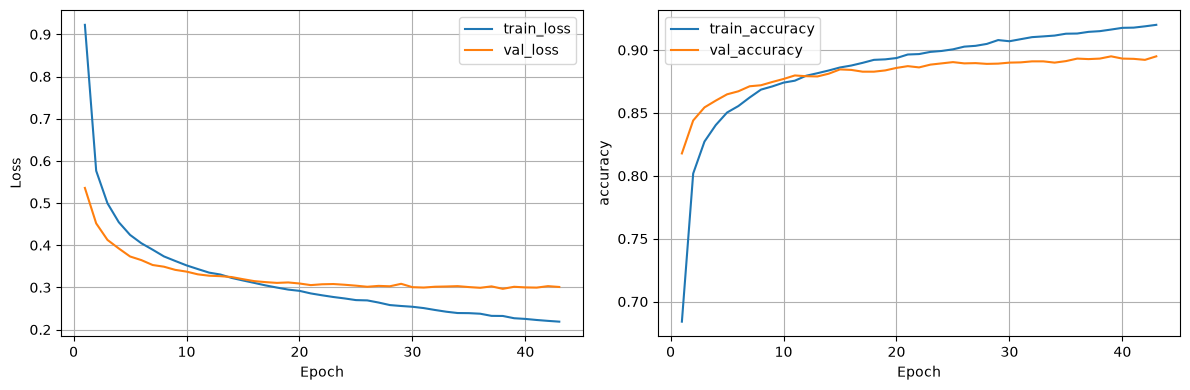

In [5]:
best_epoch=np.argmin(history.history["val_loss"])+1
best_val_loss=np.min(history.history["val_loss"])
print("最佳轮次：",best_epoch)
print("最低验证损失：",best_val_loss)


import matplotlib.pyplot as plt

epochs=range(1,len(history.history["loss"])+1)
fig,axes=plt.subplots(1,2,figsize=(12,4))

axes[0].plot(epochs,history.history["loss"],label="train_loss")
axes[0].plot(epochs,history.history["val_loss"],label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(epochs,history.history["accuracy"],label="train_accuracy")
axes[1].plot(epochs,history.history["val_accuracy"],label="val_accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("accuracy")
axes[1].grid(True)
axes[1].legend()

fig.savefig("learning_curves.png",dpi=300,bbox_inches="tight")

plt.tight_layout()
plt.show()

## 第五部分：最终评估与样本分析

In [6]:
best_model=tf.keras.models.load_model(
    "best_fashion_mnist.keras"
)#重新导入最佳模型（参数）

test_loss,test_accuracy=best_model.evaluate(X_test,y_test,verbose=1)

print("测试损失：",test_loss)
print("测试准确率：",test_accuracy)

y_proba=best_model.predict(X_test,verbose=1)
y_pred=y_proba.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 877us/step - accuracy: 0.8897 - loss: 0.3149
测试损失： 0.3148825466632843
测试准确率： 0.8896999955177307
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step


接着使用混淆矩阵分析模型容易混淆的类别:

In [7]:
from sklearn.metrics import(
    confusion_matrix,
    classification_report
)
cm=confusion_matrix(y_test,y_pred)
print("混淆矩阵：")
print(cm)

print("分类报告：")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4#控制报告内部保留四位小数
    )
)

混淆矩阵：
[[838   3  21  27   6   2  97   0   6   0]
 [  0 973   1  20   3   0   1   0   2   0]
 [ 11   0 824  10  98   0  55   0   2   0]
 [ 23   6  12 901  32   0  21   0   5   0]
 [  0   0  93  24 845   0  37   0   1   0]
 [  0   0   0   1   0 964   0  22   2  11]
 [120   1  82  30  81   0 675   0  11   0]
 [  0   0   0   0   0  16   0 973   1  10]
 [  5   1   5   5   5   2   2   5 970   0]
 [  0   0   0   0   0   8   1  57   0 934]]
分类报告：
              precision    recall  f1-score   support

           0     0.8405    0.8380    0.8393      1000
           1     0.9888    0.9730    0.9808      1000
           2     0.7938    0.8240    0.8086      1000
           3     0.8851    0.9010    0.8930      1000
           4     0.7897    0.8450    0.8164      1000
           5     0.9718    0.9640    0.9679      1000
           6     0.7593    0.6750    0.7147      1000
           7     0.9205    0.9730    0.9460      1000
           8     0.9700    0.9700    0.9700      1000
           9    

进一步分析：

<function matplotlib.pyplot.show(close=None, block=None)>

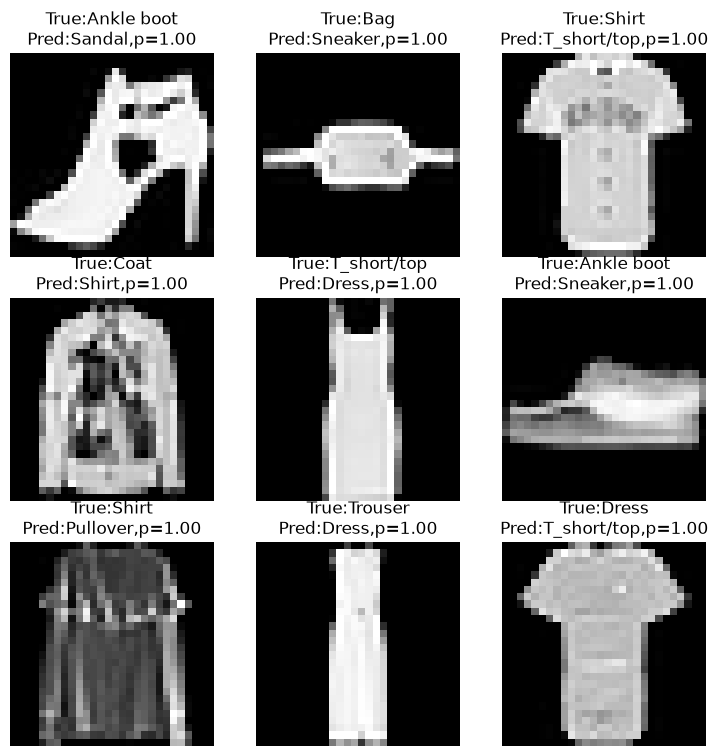

In [9]:
class_name=["T_short/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

confidence=y_proba.max(axis=1)
wrong_indices=np.where(y_pred!=y_test)[0]

sorted_wrong=wrong_indices[np.argsort(-confidence[wrong_indices])]
selected=sorted_wrong[:9]

fig,axes=plt.subplots(3,3,figsize=(9,9))

for axe,index in zip(axes.ravel(),selected):
    axe.imshow(X_test[index],cmap="gray")
    axe.set_title(
        f"True:{class_name[y_test[index]]}\n"
        f"Pred:{class_name[y_pred[index]]},"
        f"p={confidence[index]:.2f}"
    )
    axe.axis("off")

plt.tight_layout
plt.show
